# The correlation between ethinicties in Israel and trust in the Israeli Healthcare System

### Research by Ben Vann and Ben Jaitin

In [ ]:
!pip install pyreadstat
import pyreadstat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20, 'figure.figsize': (8, 4)})

### Data Loading



*   Uses the ISSP 2021 - "Health and Health Care II" - ZA No. 8000 dataset
*   Uses only the ISraeli data, based on the questionare given: ZA8000_q_il-he.pdf



In [ ]:
df = pd.read_csv('MD.csv', low_memory=False, encoding="latin1")
df.columns = df.columns.str.strip().str.lower()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44549 entries, 0 to 44548
Columns: 369 entries, unnamed: 0 to partials
dtypes: float64(14), int64(1), object(354)
memory usage: 125.4+ MB


#### Seperate to only use Israeli data

In [ ]:
df_isr = df[df['country'].astype(str).str.contains('Israel', case=False, na=False)].copy()

df_isr.info()

print(df_isr.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
Index: 1187 entries, 18007 to 19193
Columns: 369 entries, unnamed: 0 to partials
dtypes: float64(14), int64(1), object(354)
memory usage: 3.4+ MB
['unnamed: 0', 'studyno', 'version', 'doi', 'country', 'c_sample', 'c_alphan', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28', 'v29', 'v30', 'v31', 'v32', 'v33', 'v34', 'v35', 'v36', 'v37', 'v38', 'v39', 'v40', 'v41', 'v42', 'sr_v42', 'v43', 'v44', 'v45', 'v46', 'v47', 'v48', 'v49', 'v50', 'v51', 'v52', 'v53', 'v54', 'v55', 'v56', 'v57', 'v58', 'v59', 'v60', 'v61', 'v62', 'v63', 'v64', 'v65', 'v66', 'v67', 'v68', 'tw_v68a', 'tw_v68b', 'v69', 'v70', 'sex', 'birth', 'age', 'educyrs', 'at_iscd', 'au_iscd', 'ch_iscd', 'cn_iscd', 'cz_iscd', 'de_iscd', 'dk_iscd', 'fi_iscd', 'fr_iscd', 'hr_iscd', 'hu_iscd', 'il_iscd', 'in_iscd', 'is_iscd', 'it_iscd', 'jp_iscd', 'mx_iscd', 'nl

###CLEANING LOGIC

In [ ]:
# Seperate ethnicity into more general groups based on country of origin
generic_keywords = ['israeli','jewish']

def clean_ethnicity_row(row):
    val1 = str(row['il_ethn1']).strip() if pd.notna(row['il_ethn1']) and str(row['il_ethn1']) != 'nan' else None
    val2 = str(row['il_ethn2']).strip() if pd.notna(row['il_ethn2']) and str(row['il_ethn2']) != 'nan' else None
    def is_generic(val): return val and val.lower() in generic_keywords
    is_gen1, is_gen2 = is_generic(val1), is_generic(val2)

    if not val1 and not val2: return None, None
    if is_gen1 and is_gen2: return "Jewish (no other ethnicity provided)", None
    if is_gen1 and not is_gen2 and val2: return None, val2
    if not is_gen1 and is_gen2 and val1: return val1, None
    if (is_gen1 and not val2) or (is_gen2 and not val1): return "Jewish (no other ethnicity provided)", None
    return val1, val2

df_isr[['Clean_1', 'Clean_2']] = df_isr.apply(clean_ethnicity_row, axis=1, result_type='expand')
df_isr = df_isr.dropna(subset=['Clean_1', 'Clean_2'], how='all')

ashkenazi_keywords = ['Polish', 'Romanian', 'Ashkenazi']
mizrachi_keywords  = ['Moroccan', 'Iraqi', 'Sephardi', 'Mizrahi']

def map_ethnicity(val):
    if val == "Jewish (no other ethnicity provided)": return val
    val_str = str(val)
    if any(k.lower() in val_str.lower() for k in ashkenazi_keywords): return 'Ashkenazi'
    if any(k.lower() in val_str.lower() for k in mizrachi_keywords): return 'Mizrachi'
    return val_str

# Create new columns in data set for better ethnicity understanding
df_isr['Broad_1'] = df_isr['Clean_1'].apply(map_ethnicity)
df_isr['Broad_2'] = df_isr['Clean_2'].apply(map_ethnicity)



###MAP TO BROAD CATEGORIES


In [ ]:
# Define the percentage of trust given
trust_weights = {
    'Complete confidence': 100,
    'A great deal of confidence': 75,
    'Some confidence': 50,
    'Very little confidence': 25,
    'No confidence at all': 0
}

df_isr['Trust_Score'] = df_isr['v2'].map(trust_weights)

# Check if we have data
print(f"Rows with valid trust scores: {df_isr['Trust_Score'].notna().sum()}")

Rows with valid trust scores: 1170


### Calculate percentages and Visualize


=== AVERAGE TRUST SCORES (0-100 SCALE) ===
                                        N  Average Trust Score (0-100)
Group                                                                 
Ashkenazi                             152                        60.36
Other                                  67                        59.33
Jewish (no other ethnicity provided)  393                        55.93
Ukrainian                              15                        55.00
Mizrachi                              149                        54.56
Arab                                  125                        53.83
Russian                                41                        53.05
Ethiopian                               6                        41.67


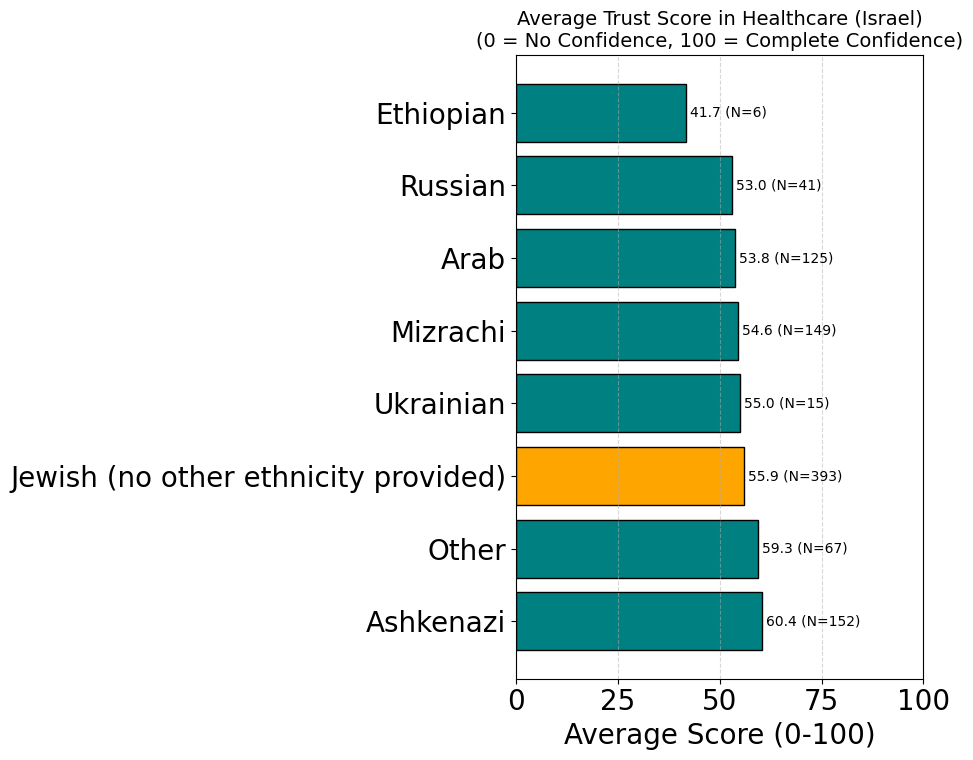

In [ ]:
# Remove Palestinian ethnicity(different healthcare system) and remove blank or not answered cells
unique_broad_groups = pd.concat([df_isr['Broad_1'], df_isr['Broad_2']]).unique()
exclude_keywords = ['Palestinian', 'No other origin group', 'nan', 'None']
target_groups = [str(g) for g in unique_broad_groups if pd.notna(g) and
                  not any(excl.lower() in str(g).lower() for excl in exclude_keywords)]

# Calculate the avarage percentage of trust in healthcare system for each group
results = []
for group in target_groups:
    mask = (df_isr['Broad_1'] == group) | (df_isr['Broad_2'] == group)
    subset = df_isr[mask]

    if not subset.empty:
        avg_score = subset['Trust_Score'].mean()
        results.append({
            'Group': group,
            'N': len(subset),
            'Average Trust Score (0-100)': avg_score
        })

# Plots a bar graph of ethnicity vs trust in Israeli healthcare
if results:
    stats_df = pd.DataFrame(results).set_index('Group')
    stats_df = stats_df.sort_values('Average Trust Score (0-100)', ascending=False)

    print("\n=== AVERAGE TRUST SCORES (0-100 SCALE) ===")
    print(stats_df.round(2))

    plt.figure(figsize=(10, 8))
    colors = ['orange' if 'provided' in x else 'teal' for x in stats_df.index]

    bars = plt.barh(stats_df.index, stats_df['Average Trust Score (0-100)'], color=colors, edgecolor='black')

    plt.title('Average Trust Score in Healthcare (Israel)\n(0 = No Confidence, 100 = Complete Confidence)', fontsize=14)
    plt.xlabel('Average Score (0-100)')
    plt.xlim(0, 100)
    plt.grid(axis='x', linestyle='--', alpha=0.5)

    # Add text labels
    for bar, n, score in zip(bars, stats_df['N'], stats_df['Average Trust Score (0-100)']):
        plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                  f'{score:.1f} (N={n})', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("No matching groups found.")

### Mapping Healthcare Satisfaction

In [ ]:
satisfaction_weights = {
    'Completely dissatisfied': 0,
    'Very dissatisfied': 17,
    'Fairly dissatisfied': 33,
    'Neither satisfied nor dissatisfied': 50,
    'Fairly satisfied': 67,
    'Very satisfied': 83,
    'Completely satisfied': 100
}

# 1. Clean the column (strip whitespace)
# 2. Map the values
df_isr['v44_numeric'] = df_isr['v44'].astype(str).str.strip().map(satisfaction_weights)

print("Mapped v44 Satisfaction Scores.")
print(df_isr[['v44', 'v44_numeric']].head())

Mapped v44 Satisfaction Scores.
                                      v44  v44_numeric
18007                    Fairly satisfied         67.0
18008                    Fairly satisfied         67.0
18009                    Fairly satisfied         67.0
18010  Neither satisfied nor dissatisfied         50.0
18011  Neither satisfied nor dissatisfied         50.0


### Visualize Healthcare System Satisfaction vs. Trust

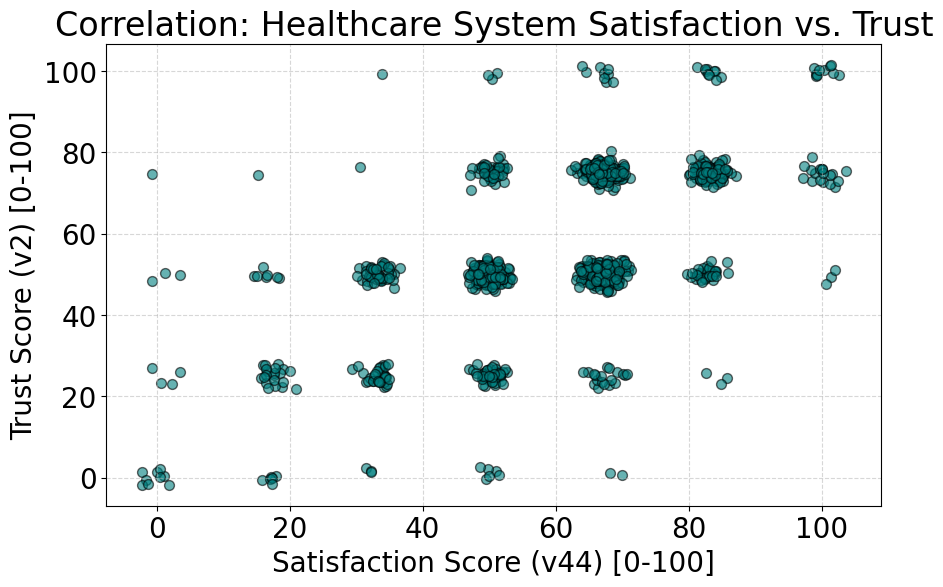

In [ ]:
# Scatterplot Visualization
plt.figure(figsize=(10, 6))

# Drop rows where either score is missing for the plot
plot_data = df_isr.dropna(subset=['Trust_Score', 'v44_numeric'])

# Add random 'jitter' to points so they don't overlap perfectly (since values are discrete like 0, 17, 33...)
jitter_x = plot_data['v44_numeric'] + np.random.normal(0, 1.5, len(plot_data))
jitter_y = plot_data['Trust_Score'] + np.random.normal(0, 1.5, len(plot_data))

plt.scatter(jitter_x, jitter_y, alpha=0.6, c='teal', edgecolor='k', s=50)

plt.title('Correlation: Healthcare System Satisfaction vs. Trust')
plt.xlabel('Satisfaction Score (v44) [0-100]')
plt.ylabel('Trust Score (v2) [0-100]')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

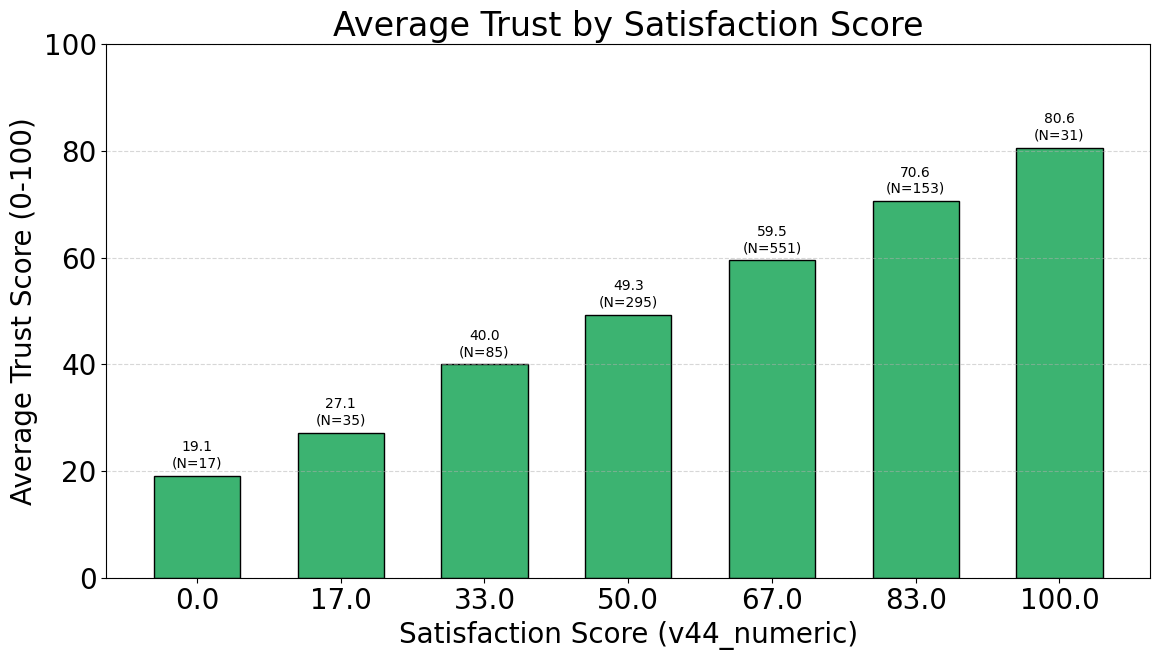

In [ ]:
# Bar graph visualization
sat_numeric_stats = df_isr.groupby('v44_numeric')['Trust_Score'].agg(['mean', 'count'])

plt.figure(figsize=(12, 7))

# Create vertical bars
bars = plt.bar(sat_numeric_stats.index.astype(str), sat_numeric_stats['mean'],
               color='mediumseagreen', edgecolor='black', width=0.6)

plt.title('Average Trust by Satisfaction Score')
plt.xlabel('Satisfaction Score (v44_numeric)')
plt.ylabel('Average Trust Score (0-100)')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Add text labels
for bar, n, score in zip(bars, sat_numeric_stats['count'], sat_numeric_stats['mean']):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1,
             f'{score:.1f}\n(N={n})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Calculate and visualize Religion distribution in every ethnicity

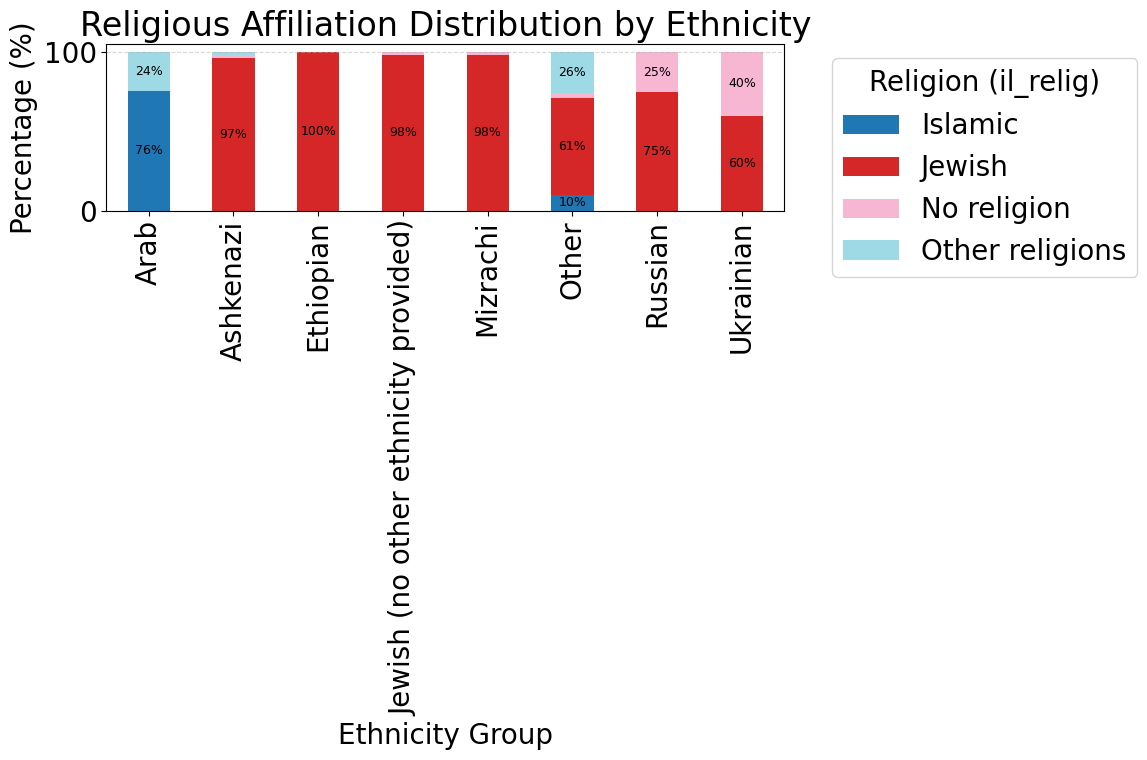

In [ ]:
# Filter the dataframe
bar_data = df_isr[df_isr['Broad_1'].isin(target_groups)]

# Create Crosstab: Ethnicity vs Religion (Normalized to show Percentage)
# normalize='index' ensures each bar sums to 100%
relig_ethnicity_ct = pd.crosstab(bar_data['Broad_1'], bar_data['il_relig'], normalize='index') * 100

# Plot in bar graph
ax = relig_ethnicity_ct.plot(kind='bar', stacked=True, figsize=(12, 8), colormap='tab20')

plt.title('Religious Affiliation Distribution by Ethnicity')
plt.xlabel('Ethnicity Group')
plt.ylabel('Percentage (%)')
plt.legend(title='Religion (il_relig)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Add percentage labels on the bars
for c in ax.containers:
    # Only label segments that are large enough (>5%) to be readable
    labels = [f'{v.get_height():.0f}%' if v.get_height() > 5 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=9)

plt.show()

### Calculate and visualize trust in healthcare vs religion

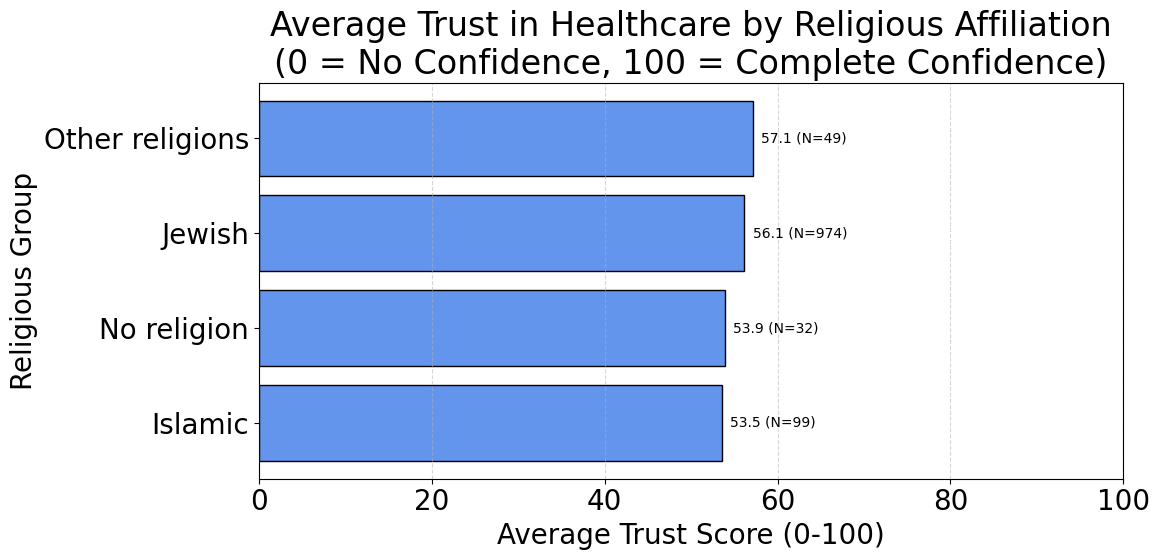

In [ ]:
# Group by Religion and calculate the mean Trust Score
relig_trust_stats = df_isr.groupby('il_relig')['Trust_Score'].agg(['mean', 'count'])

# 2. Sort values for a better looking chart
relig_trust_stats = relig_trust_stats.sort_values('mean', ascending=True)

# 3. Plot
plt.figure(figsize=(12, 6))

# Create horizontal bars
bars = plt.barh(relig_trust_stats.index, relig_trust_stats['mean'], color='cornflowerblue', edgecolor='black')

plt.title('Average Trust in Healthcare by Religious Affiliation\n(0 = No Confidence, 100 = Complete Confidence)')
plt.xlabel('Average Trust Score (0-100)')
plt.ylabel('Religious Group')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add labels to bars
for bar, n, score in zip(bars, relig_trust_stats['count'], relig_trust_stats['mean']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{score:.1f} (N={n})', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Calculate and visualize Healthcare satisfaction vs ethnicity

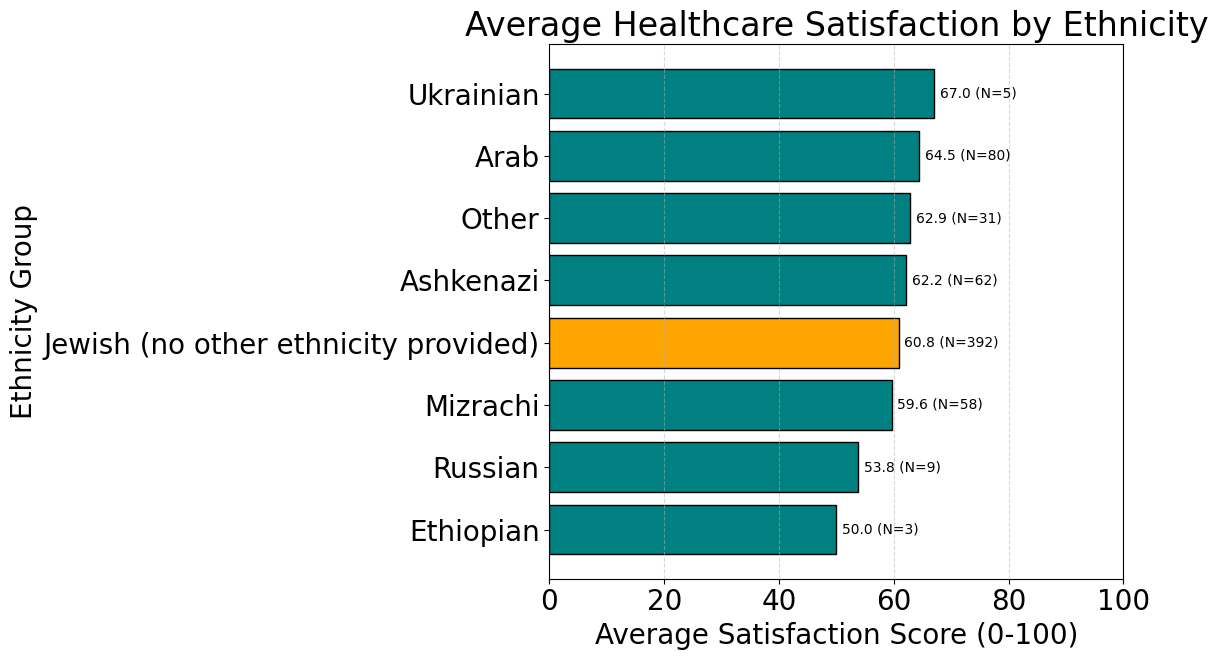

In [ ]:
# Filter data
ethnicity_sat_data = df_isr[df_isr['Broad_1'].isin(target_groups)]

# Group by Ethnicity and calculate mean
ethnicity_sat_stats = ethnicity_sat_data.groupby('Broad_1')['v44_numeric'].agg(['mean', 'count'])
ethnicity_sat_stats = ethnicity_sat_stats.sort_values('mean', ascending=True)

colors = []
for ethnicity in ethnicity_sat_stats.index:
    if ethnicity == "Jewish (no other ethnicity provided)":
        colors.append('orange')
    else:
        colors.append('teal')

# 5. Plot
plt.figure(figsize=(12, 7))

bars = plt.barh(ethnicity_sat_stats.index, ethnicity_sat_stats['mean'],
                color=colors, edgecolor='black')

plt.title('Average Healthcare Satisfaction by Ethnicity')
plt.xlabel('Average Satisfaction Score (0-100)')
plt.ylabel('Ethnicity Group')
plt.xlim(0, 100)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Add labels
for bar, n, score in zip(bars, ethnicity_sat_stats['count'], ethnicity_sat_stats['mean']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{score:.1f} (N={n})', va='center', fontsize=10)

plt.tight_layout()
plt.show()

### Insight



*   We have noticed that Ashkenazi jews are the most trusting group in the healthcare system.
*   Ethiopeans, Arabs, Russians, and Mizrachi jews, are the most non-trusting groups.




*   There is a linear correlation between trust and satisfaction in the healthcare system.
*   But, ethnic groups like Arabs, where trust in the system is low, have a surprisingly high satisfaction from it.



*   Further research might be needed to see correlation between socioeconomic or culture differences and trust in the Israeli healthcare system
*   Also, need to find out the general health of each ethnicity, and the need for healthcare in each one.










### Further research Questions:



*   #### How do different ethnicities in Israel view the healthcare system?
*   #### How do socioeconomic attributes of different ethnicities in Israel affect the trust in  the healthcare system?
*   #### Does different trust in healthcare result in different healthcare needs?
*   #### Does religion play a part in that Trust? Are more religious ethnicities prone to trust less in the healthcare system?
*   #### How can we help gain that trust with low-trusting ethnicities?
*   #### What other factors come into question? Can we predict healthcare trust from other questions based on quality of life/lifestyle?




## Out proposed Research direction is:
# Why are different Israeli ethnicities view and trust the healthcare system so differently?